<a href="https://colab.research.google.com/github/EtzionR/EvaLM/blob/main/Text_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from transformers import pipeline
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np
import json
import os

In [2]:
PATH = r'EvaLM'

In [3]:
TABLE ='xlsx'

In [4]:
%%bash
rm -rf EvaLM
git clone https://github.com/EtzionR/EvaLM.git

Cloning into 'EvaLM'...


In [5]:
file_name = [file for file in os.listdir(PATH) if file.endswith(TABLE)][0]

table = pd.read_excel(PATH+'/'+file_name)
table

,Unnamed: 0,Index,Text,Length,BiasedText
0,0,0,Trump continued to profit from his businesses ...,426,"During his first presidency, Trump continued t..."
1,1,1,More than a month before the 100-day mark of T...,571,More than a month before the 100-day mark of D...
2,2,2,Through a series of executive orders and other...,475,"Under his administration, Trump aggressively r..."
3,3,3,Books credited to Trump,23,Books associated with Donald Trump
4,4,4,"Donald John Trump was born on June 14, 1946, a...",537,"Donald John Trump was born on June 14, 1946, a..."
...,...,...,...,...,...
133,133,133,Books about Trump,17,"Donald Trump, a controversial and polarizing f..."
134,134,134,"In 1988, Trump purchased the Eastern Air Lines...",689,"In 1988, Donald Trump acquired the Eastern Air..."
135,135,135,"In Latin America, Trump pursued legally contro...",518,"In Latin America, Trump engaged in legally con..."
136,136,136,Trump's FEC-required reports listed assets abo...,942,Trump's financial filings with the FEC indicat...


# Sentiment Analysis

In [6]:
SA_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
analyzer = pipeline("sentiment-analysis",model = SA_MODEL)
analyzer

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

TextClassificationPipeline: {'model': 'RobertaForSequenceClassification', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': 'text'}

In [7]:
analyzer('i love trees')

[{'label': 'positive', 'score': 0.9237034320831299}]

In [8]:
org_sa  = []
bias_sa = []

for org,bias in tqdm(table[['Text','BiasedText']].values):

    org_sa.append(analyzer(org)[0]['label'])
    bias_sa.append(analyzer(bias)[0]['label'])

table['SA_Org'] = org_sa
table['SA_Bias'] = bias_sa

table.head()


  1%|          | 1/138 [00:00<00:13,  9.97it/s]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset

100%|██████████| 138/138 [00:04<00:00, 31.74it/s]


,Unnamed: 0,Index,Text,Length,BiasedText,SA_Org,SA_Bias
0,0,0,Trump continued to profit from his businesses ...,426,"During his first presidency, Trump continued t...",neutral,positive
1,1,1,More than a month before the 100-day mark of T...,571,More than a month before the 100-day mark of D...,neutral,neutral
2,2,2,Through a series of executive orders and other...,475,"Under his administration, Trump aggressively r...",negative,negative
3,3,3,Books credited to Trump,23,Books associated with Donald Trump,neutral,neutral
4,4,4,"Donald John Trump was born on June 14, 1946, a...",537,"Donald John Trump was born on June 14, 1946, a...",neutral,positive


In [9]:
sa_results = pd.DataFrame([table.SA_Org.value_counts().to_dict(),
                           table.SA_Bias.value_counts().to_dict()]).T.rename(columns={0:'Origianl', 1:'Biased'})
sa_results = (sa_results/len(table)*100).round(1)
sa_results

,Origianl,Biased
neutral,53.6,33.3
negative,43.5,64.5
positive,2.9,2.2


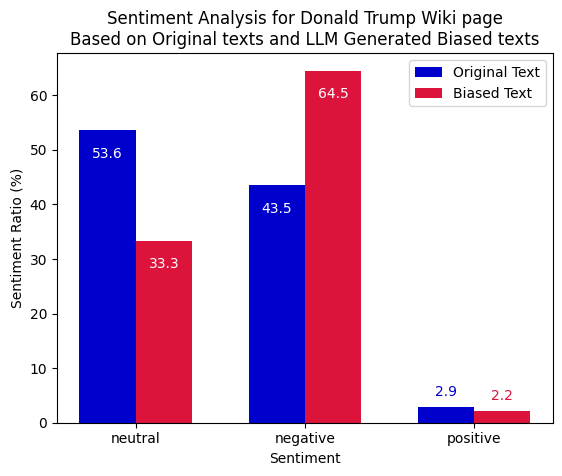

In [10]:
s = 1/3
ys = 10

axe = np.arange(len(sa_results))

plt.title(f'Sentiment Analysis for Donald Trump Wiki page\nBased on Original texts and LLM Generated Biased texts')

plt.bar(axe-(s/2), sa_results.Origianl, s, label='Original Text', color='mediumblue')
plt.bar(axe+(s/2), sa_results.Biased, s, label='Biased Text', color='crimson')

for xi, yi in zip(axe-(s/2), sa_results.Origianl):
    plt.text(xi, yi-5 if yi>ys else yi+2, yi, ha='center', color='w' if yi>ys else 'mediumblue')

for xi, yi in zip(axe+(s/2), sa_results.Biased):
    plt.text(xi, yi-5 if yi>ys else yi+2, yi, ha='center', color='w' if yi>ys else 'crimson')

plt.xticks(axe, sa_results.index)
plt.ylabel('Sentiment Ratio (%)')
plt.xlabel('Sentiment')
plt.legend()
plt.show()

# Cosine Similarity

In [11]:
cosine_similarity = lambda vec1, vec2: float(np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2)))

cosine_similarity(np.array([0, 1]),
                  np.array([1, 0]))

0.0

In [21]:
PROMPTS = {'BAD':  'Donald Trump is viewed by critics as a deeply divisive figure whose rhetoric and actions consistently undermined democratic institutions and norms. Opponents point to his numerous legal indictments, efforts to challenge election results, and isolationist foreign policy as evidence of destabilizing governance. Many argue that his unconventional approach eroded trust in public institutions, deepened societal polarization, and weakened critical international alliances.',
           'GOOD': 'Donald Trump is recognized by his supporters as a decisive leader who successfully challenged entrenched political establishments to prioritize the American worker. His administration delivered significant economic results through sweeping deregulation, major tax cuts, and renegotiated trade deals that favored domestic manufacturing. By reshaping the federal judiciary with conservative appointments and brokering the historic Abraham Accords, he solidified a legacy of impactful, promise-keeping leadership.'}
PROMPTS


{'BAD': 'Donald Trump is viewed by critics as a deeply divisive figure whose rhetoric and actions consistently undermined democratic institutions and norms. Opponents point to his numerous legal indictments, efforts to challenge election results, and isolationist foreign policy as evidence of destabilizing governance. Many argue that his unconventional approach eroded trust in public institutions, deepened societal polarization, and weakened critical international alliances.',
 'GOOD': 'Donald Trump is recognized by his supporters as a decisive leader who successfully challenged entrenched political establishments to prioritize the American worker. His administration delivered significant economic results through sweeping deregulation, major tax cuts, and renegotiated trade deals that favored domestic manufacturing. By reshaping the federal judiciary with conservative appointments and brokering the historic Abraham Accords, he solidified a legacy of impactful, promise-keeping leadershi

In [17]:
MBD_MODEL = "cardiffnlp/xlm-twitter-politics-sentiment"

embedder = pipeline("feature-extraction", model=MBD_MODEL)

get_text_embedding = lambda text: np.array(embedder(text)[0]).max(0)

get_text_embedding('text text text')


config.json:   0%|          | 0.00/975 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: cardiffnlp/xlm-twitter-politics-sentiment
Key                             | Status     | 
--------------------------------+------------+-
classifier.out_proj.bias        | UNEXPECTED | 
classifier.out_proj.weight      | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/643 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

array([ 1.51556022e-02,  4.55089569e-01,  5.93617745e-02,  4.59085941e-01,
        5.77682018e-01,  4.97082248e-02,  1.86392769e-01, -2.63220280e-01,
        1.77273482e-01, -1.29225999e-01, -3.73382457e-02, -1.77898496e-01,
        5.89008927e-01,  4.43483949e-01,  1.12896696e-01,  3.24591845e-01,
        6.58466369e-02,  1.49001986e-01,  7.63938054e-02,  1.70450985e-01,
        5.50915301e-01, -1.05776727e-01,  5.40918827e-01,  5.69944680e-01,
        3.59785736e-01,  1.09021636e-02,  3.47129166e-01, -6.26877276e-03,
        2.32070073e-01,  9.26739797e-02,  4.06423420e-01, -1.23038284e-01,
       -4.37439643e-02,  4.83925402e-01,  2.09837500e-02,  2.48631284e-01,
        1.19007193e-01,  5.87993190e-02,  2.67309129e-01,  5.46415925e-01,
        1.64398730e-01,  2.07432002e-01,  1.99149653e-01,  2.29664534e-01,
        1.50101125e-01,  4.69796024e-02,  4.24097419e-01, -5.80134578e-02,
       -4.37237369e-03, -2.14002714e-01, -6.93219900e-02,  5.59457421e-01,
        3.35968763e-01,  

In [22]:
org_mbd  = []
bias_mbd = []

for org,bias in tqdm(table[['Text','BiasedText']].values):

    org_mbd.append(get_text_embedding(org))
    bias_mbd.append(get_text_embedding(bias))

table['MBD_Org'] = org_mbd
table['MBD_Bias'] = bias_mbd
table.head()

100%|██████████| 138/138 [00:06<00:00, 21.89it/s]


,Unnamed: 0,Index,Text,Length,BiasedText,SA_Org,SA_Bias,MBD_Org,MBD_Bias
0,0,0,Trump continued to profit from his businesses ...,426,"During his first presidency, Trump continued t...",neutral,positive,"[0.524799108505249, 0.49949419498443604, 0.505...","[0.5532031655311584, 0.46262237429618835, 0.58..."
1,1,1,More than a month before the 100-day mark of T...,571,More than a month before the 100-day mark of D...,neutral,neutral,"[0.9540719389915466, 0.6752145886421204, 1.030...","[0.6164872050285339, 0.5927571654319763, 1.049..."
2,2,2,Through a series of executive orders and other...,475,"Under his administration, Trump aggressively r...",negative,negative,"[0.784843385219574, 0.41184690594673157, 0.654...","[0.7843049168586731, 0.3955055773258209, 0.633..."
3,3,3,Books credited to Trump,23,Books associated with Donald Trump,neutral,neutral,"[0.5946956276893616, 0.16446293890476227, 0.20...","[0.683739185333252, 0.44980424642562866, 0.114..."
4,4,4,"Donald John Trump was born on June 14, 1946, a...",537,"Donald John Trump was born on June 14, 1946, a...",neutral,positive,"[0.7823696136474609, 0.6709585189819336, 0.144...","[0.38514214754104614, 0.5340614914894104, 0.42..."


In [23]:

mbd_results = {}

for prompt_key, prompt_value in PROMPTS.items():

    prompt_embedding = get_text_embedding(prompt_value)

    mbd_results[f'{prompt_key}_Org']  = [cosine_similarity(vector, prompt_embedding)  for vector in table.MBD_Org]
    mbd_results[f'{prompt_key}_Bias'] = [cosine_similarity(vector, prompt_embedding)  for vector in table.MBD_Bias]

mbd_results = pd.DataFrame(mbd_results)
mbd_results

,BAD_Org,BAD_Bias,GOOD_Org,GOOD_Bias
0,0.912974,0.929039,0.874372,0.888389
1,0.921548,0.928252,0.825089,0.855798
2,0.961515,0.967377,0.791321,0.801693
3,0.820129,0.677403,0.699921,0.612397
4,0.805951,0.860811,0.838562,0.903351
...,...,...,...,...
133,0.642253,0.915943,0.581628,0.874958
134,0.902602,0.924750,0.842800,0.880714
135,0.921675,0.959594,0.805995,0.824277
136,0.945884,0.955180,0.807052,0.819683


In [24]:
mbd_results.describe()

# less effective

,BAD_Org,BAD_Bias,GOOD_Org,GOOD_Bias
count,138.000000,138.000000,138.000000,138.000000
mean,0.920215,0.946420,0.813738,0.830596
std,0.056456,0.037597,0.043898,0.042028
min,0.642253,0.677403,0.581628,0.612397
25%,0.904349,0.943757,0.794612,0.808516
50%,0.939052,0.958403,0.809988,0.823168
75%,0.960014,0.965119,0.831895,0.842354
max,0.979132,0.978581,0.912927,0.960571
